In [21]:
import numpy as np
import pandas as pd
# import statsmodels.api as sm

import statsmodels.formula.api as smf
from matplotlib import pyplot as plt

# from sklearn.linear_model import LogisticRegressionCV, LassoCV, RidgeCV
# 
# import patsy 
# 
# from statsmodels import graphics
# from statsmodels.stats import multitest
# from statsmodels.stats.contrast import ContrastResults
# 
# from scipy import stats


from visual.plot import violin_plot
from atrophy_index import msa_ai

import warnings
warnings.filterwarnings("ignore")

font = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 24,
       }
font_title = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 36,
       }
font_body = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        'size': 18,
       }

plt.style.use('default')

#### Configuration

In [27]:
data   = pd.read_excel("../data/MSA_volume_collection_20250605.xlsx", sheet_name="Master")

In [28]:
ref_sheet   = "../data/brain_volumes_hcp_062025.xlsx"
adj_formula = "{} ~ 1 + Age"
age_lim     = [40, 80]

In [30]:
group_keys_ = ["HC", "PAF", "DLB", "PD", "MSA", "Incon"]
group_names = ["HC", "PAF", "DLB", "PD", "MSA", "Incon"]
colors = plt.get_cmap("plasma",lut=9)

### Comparison region of interest (Pallidum, Putamen, Lentiform nucleus, and Cerebellum, Brainstem, and Olivopontocerebellum)

In [41]:
wscore_pa = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, feature_set={"PA": ["PallidumTotalVolume_"]}, formula=adj_formula, age_lim=age_lim, a_fun=np.sum)
wscore_pt = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, feature_set={"PT": ["PutamenTotalVolume_"]}, formula=adj_formula, age_lim=age_lim, a_fun=np.sum)
wscore_ln = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, feature_set={"PA": ["PallidumTotalVolume_"], "PT":["PutamenTotalVolume_"]}, formula=adj_formula, age_lim=age_lim, a_fun=np.mean)

wscore_cb  = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, feature_set={"CB": ["CerebellumTotalVolume_"]}, formula=adj_formula, age_lim=age_lim, a_fun=np.sum)
wscore_bs  = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, feature_set={"BS": ["BrainstemVolume_"]}, formula=adj_formula, age_lim=age_lim, a_fun=np.sum)
wscore_opc = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, feature_set={"CB": ["CerebellumTotalVolume_"], "BS":["BrainstemVolume_"]}, formula=adj_formula, age_lim=age_lim, a_fun=np.mean)

Fitting model for formula : PA ~ 1 + Age
Fitting model for formula : PT ~ 1 + Age
Fitting model for formula : PA ~ 1 + Age
Fitting model for formula : PT ~ 1 + Age
Fitting model for formula : CB ~ 1 + Age
Fitting model for formula : BS ~ 1 + Age
Fitting model for formula : CB ~ 1 + Age
Fitting model for formula : BS ~ 1 + Age


#### Cross-sectional analysis at baseline

In [44]:
df = data[data["Visit"]==0].reset_index(drop=True).copy()
df["pt_wscore"]  = wscore_pt.compute_msa_ai(df)
df["pa_wscore"]  = wscore_pa.compute_msa_ai(df)
df["ln_wscore"]  = wscore_ln.compute_msa_ai(df)
df["cb_wscore"]  = wscore_cb.compute_msa_ai(df)
df["bs_wscore"]  = wscore_bs.compute_msa_ai(df)
df["opc_wscore"] = wscore_opc.compute_msa_ai(df)

struct_keys_ = ["pt_wscore", "pa_wscore", "ln_wscore" , "cb_wscore", "bs_wscore", "opc_wscore"] 
struct_names = ["Putamen (w-score)", "Pallidum (w-score)", "Lentiform Nucleus (w-score)", "Cerebellum (w-score)", "Brainstem (w-score)", "Olivopontocerebellum (w-score)"] 

                            OLS Regression Results                            
Dep. Variable:              pt_wscore   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     12.88
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           3.49e-14
Time:                        16:36:38   Log-Likelihood:                -430.66
No. Observations:                 265   AIC:                             877.3
Df Residuals:                     257   BIC:                             906.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

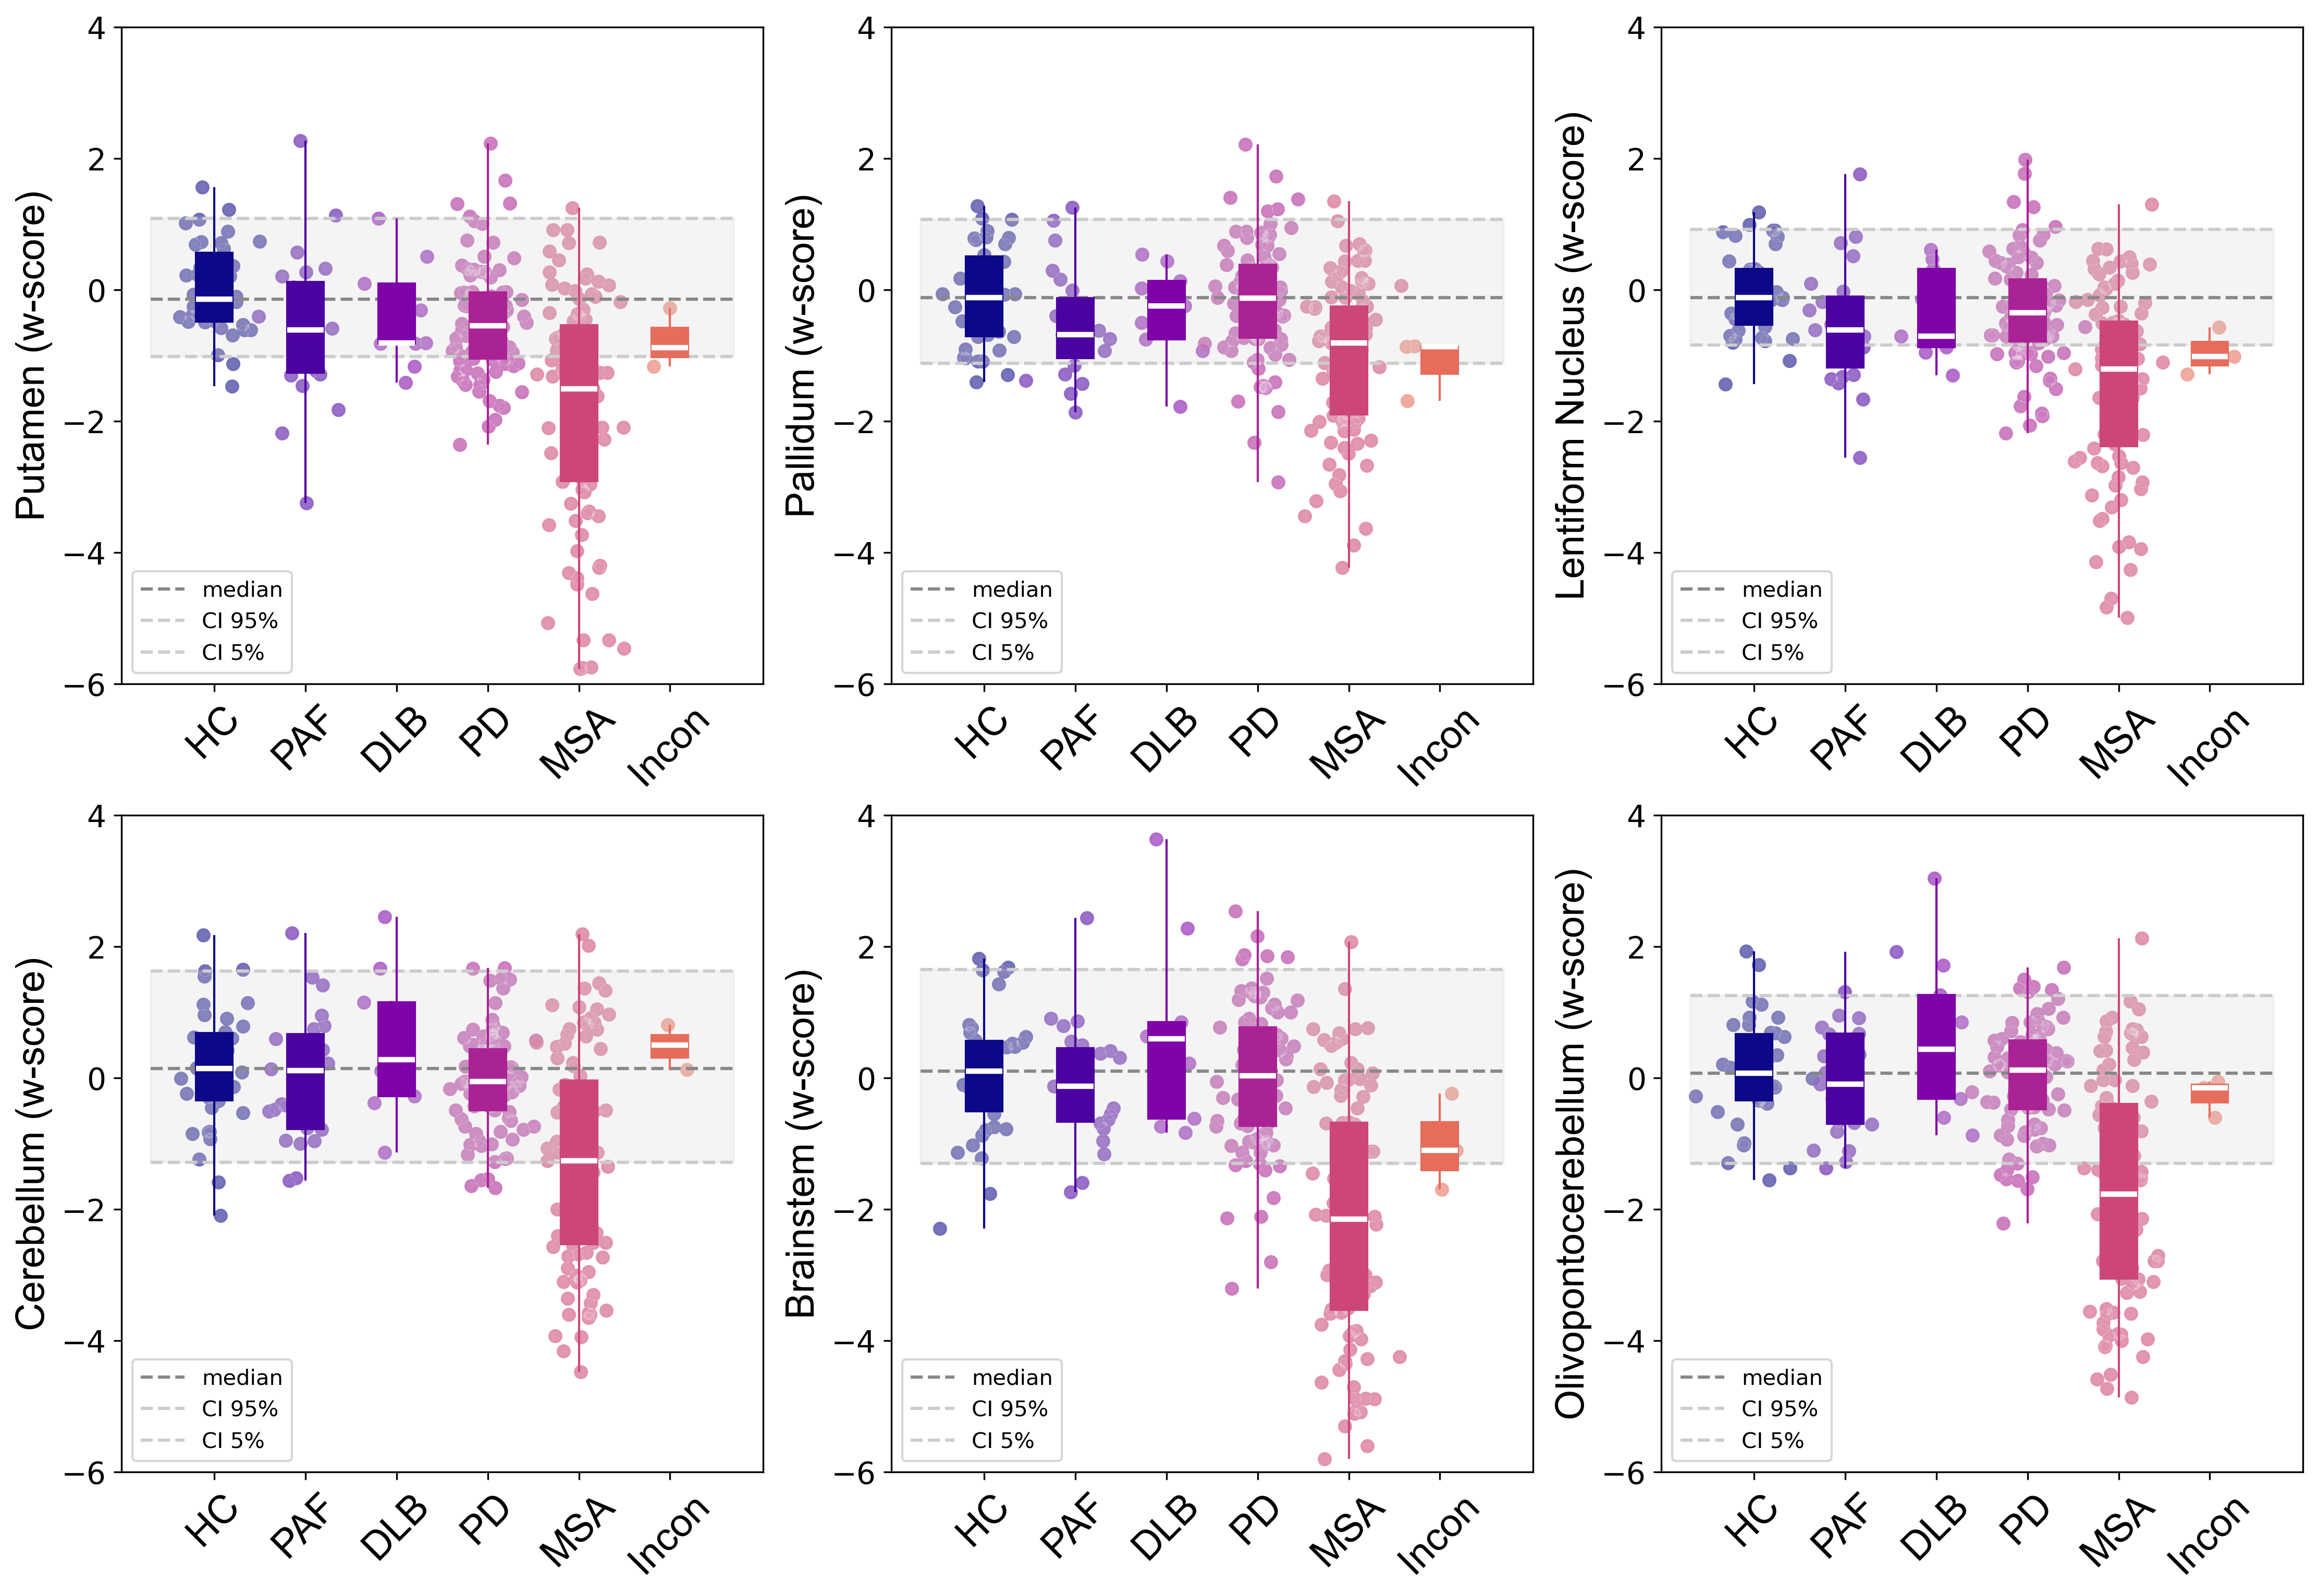

In [45]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12), dpi=300)
axs = axs.flatten()

# Iterate through each structural measure
for i, str_key in enumerate(struct_keys_):
    mdl = smf.ols(formula="{} ~ 1 + Age + Sex".format(str_key),data=df).fit()
    emputed_rsquared = np.abs(mdl.rsquared_adj) 
    
    mdl = smf.ols(formula="{} ~ 1 + I((Group=='MSA')) + Age + Sex".format(str_key),data=df).fit()
    full_rsquared = mdl.rsquared_adj
    f2 = (full_rsquared - emputed_rsquared) / (1-full_rsquared)

    mdl = smf.ols(formula="{} ~ 1 + C(Group,Treatment(reference='HC')) + Age + Sex".format(str_key),data=df).fit()
    print(mdl.summary())
    
    print("Emputed model r-squared (residual variance) = {:.4f}".format(emputed_rsquared))
    print("Variance explained by the predictor  = {:.4f}".format(full_rsquared - emputed_rsquared))
    print("Cohen's f2 = {:.2f}".format(f2))

    # Plot group-wise data
    ax = axs[i]
    for j, grp_key in enumerate(group_keys_):
        df_group = df[df.Group == grp_key].reset_index(drop=True)
        data_vals = df_group[str_key].dropna().to_numpy()

        if grp_key == "HC" and data_vals.size > 0:
            median = np.percentile(data_vals, 50)
            ci_95 = np.percentile(data_vals, 95)
            ci_5 = np.percentile(data_vals, 5)

            x_range = [-0.7, len(group_keys_) - 0.3]
            ax.plot(x_range, [median] * 2, '--', color="#888", zorder=-100)
            ax.plot(x_range, [ci_95] * 2, '--', color="#CCC", zorder=-100)
            ax.plot(x_range, [ci_5] * 2, '--', color="#CCC", zorder=-100)
            ax.fill_between(x_range, ci_5, ci_95, color="#CCC", alpha=0.2, zorder=-200)
            ax.legend(["median", "CI 95%", "CI 5%"], loc="lower left")

        # Plot violin/scatter
        violin_plot(
            data_vals,
            ax,
            j,
            color=colors.colors[j],
            width=2,
            scatter=True,
            violin=False,
        )

    # Axes formatting
    ax.set_ylabel(struct_names[i], fontdict=font_body)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)

    ax.set_ylim([-6, 4])
    ax.set_xticks(np.arange(len(group_keys_)))
    ax.set_xticklabels(group_names, fontdict=font_body, rotation=45)
    
     # Find MSA subjects above ci_5
    hc_vals = df[df.Group == "HC"][str_key].dropna()
    if hc_vals.size > 0:
        ci_5 = np.percentile(hc_vals, 5)
        df_msa = df[df.Group == "MSA"].copy()
        msa_above_threshold = df_msa[df_msa[str_key] > ci_5]
        if not msa_above_threshold.empty:
            print(f"\nMSA subjects with {str_key} above HC 5th percentile (ci_5 = {ci_5:.2f}):")
            print(msa_above_threshold["Subject"].to_list())

#### Longitudinal analysis

In [48]:
df = data[((data.Group=="HC") | (data.Group=="PD") | (data.Group=="MSA"))].reset_index(drop=True).copy()
df["pt_wscore"]  = wscore_pt.compute_msa_ai(df)
df["pa_wscore"]  = wscore_pa.compute_msa_ai(df)
df["ln_wscore"]  = wscore_ln.compute_msa_ai(df)
df["cb_wscore"]  = wscore_cb.compute_msa_ai(df)
df["bs_wscore"]  = wscore_bs.compute_msa_ai(df)
df["opc_wscore"] = wscore_opc.compute_msa_ai(df)

struct_keys_ = ["pt_wscore", "pa_wscore", "ln_wscore" , "cb_wscore", "bs_wscore", "opc_wscore"] 
struct_names = ["Putamen (w-score)", "Pallidum (w-score)", "Lentiform Nucleus (w-score)", "Cerebellum (w-score)", "Brainstem (w-score)", "Olivopontocerebellum (w-score)"] 

group_keys_ = ["HC", "PD", "MSA"]
group_names = ["HC", "PD", "MSA"]

                            OLS Regression Results                            
Dep. Variable:                  Delta   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.201
Method:                 Least Squares   F-statistic:                     12.59
Date:                Mon, 16 Jun 2025   Prob (F-statistic):           1.50e-05
Time:                        16:43:02   Log-Likelihood:                -33.206
No. Observations:                  93   AIC:                             72.41
Df Residuals:                      90   BIC:                             80.01
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

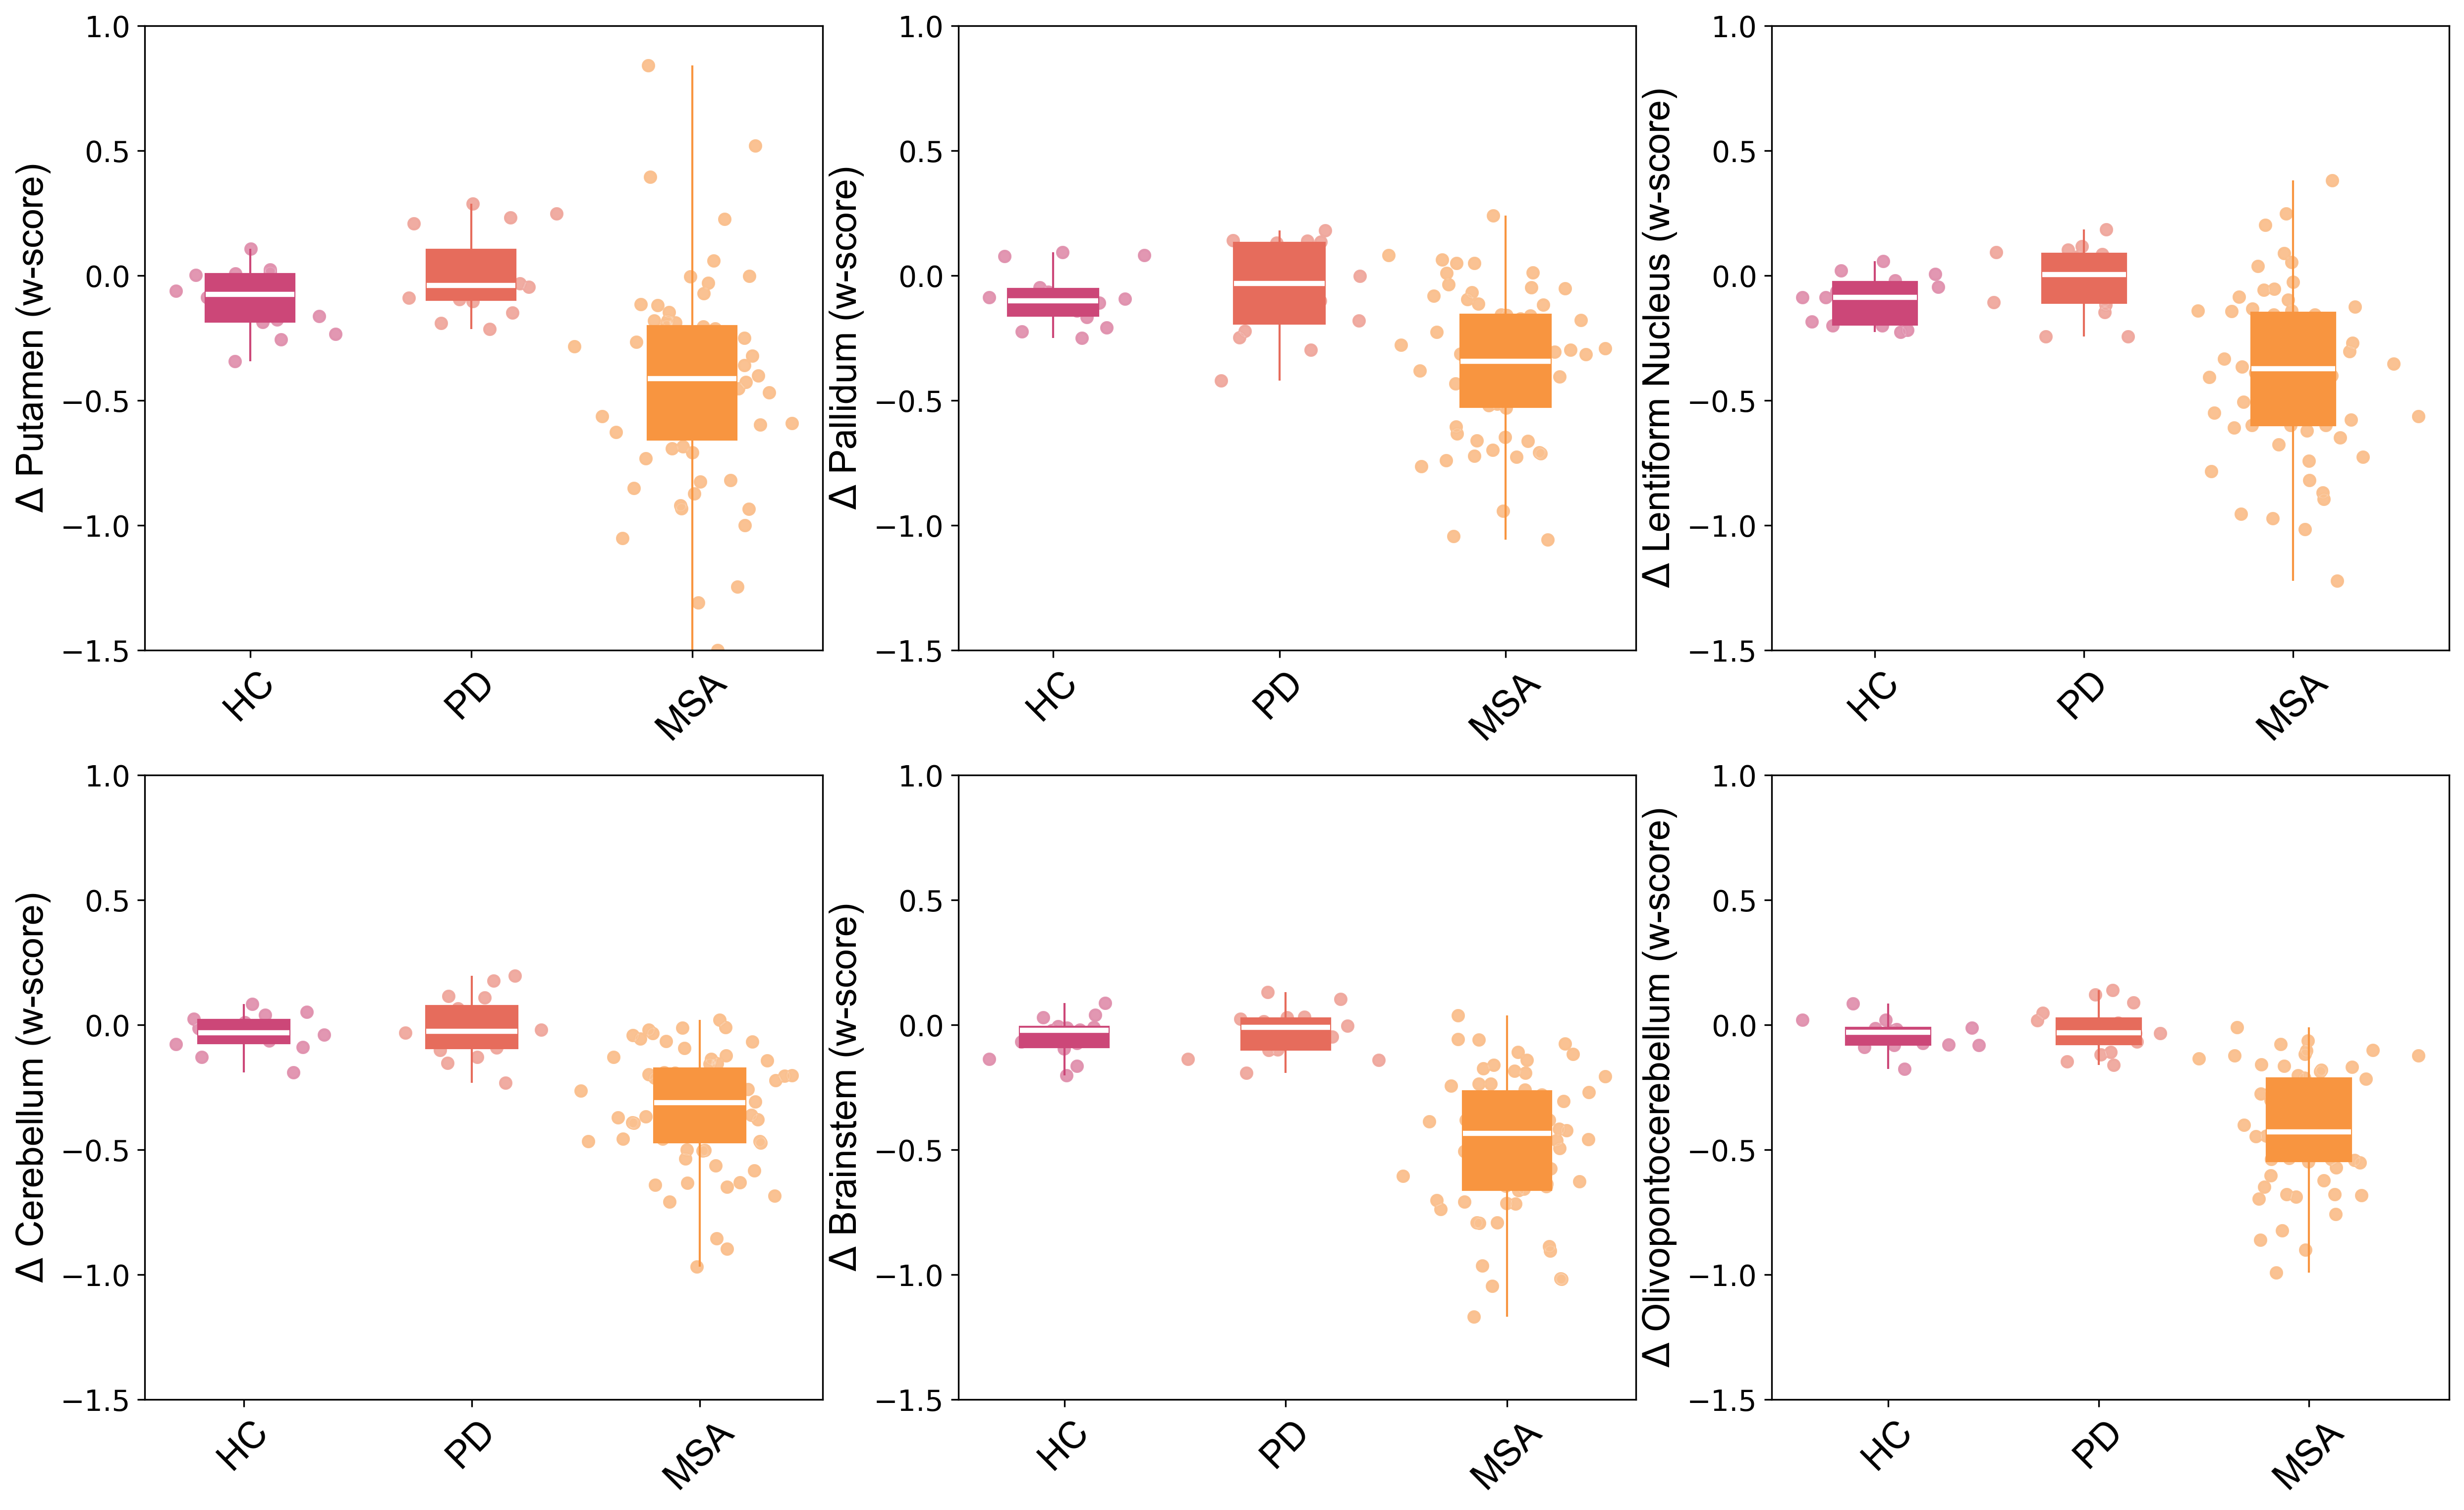

In [52]:
fig = plt.figure(1, figsize=[20,12], dpi=300)
axs = fig.subplots(2,3).flatten()
Subject_ID = df[df.Visit == 12].reset_index().Subject

# print(Subject_ID)

for i, str_key in enumerate(struct_keys_):
    delta = []
    group = []
    age   = []
    sex   = []
    subject_ids = []
    
    for sid in Subject_ID:
        _df0_ = df[(df.Subject == sid) & (df.Visit == 0)]
        _df1_ = df[(df.Subject == sid) & (df.Visit == 12)]

        if _df0_.empty or _df1_.empty:
            continue

        deltar = _df1_[str_key].values[0] - _df0_[str_key].values[0]
        delta.append(deltar)
        group.append(_df0_["Group"].values[0])
        age.append(_df0_["Age"].values[0])
        sex.append(_df0_["Sex"].values[0])
        subject_ids.append(sid)

    ax = axs[i]
    df_ = pd.DataFrame({
        "Subject_ID": subject_ids,
        "Delta": delta,
        "Group": group,
        "Age": age,
        "Sex": sex
    })

    # Model: Age + Sex
    mdl = smf.ols(formula="Delta ~ 1 + Age + Sex", data=df_).fit()
    emputed_rsquared = mdl.rsquared_adj

    # Model: Group only
    mdl = smf.ols(formula="Delta ~ -1 + C(Group, Treatment(reference='PD'))", data=df_).fit()
    print(mdl.summary())

    full_rsquared = mdl.rsquared_adj
    f2 = (full_rsquared - emputed_rsquared) / (full_rsquared)

    print("Emputed model r-squared (residual variance) = {:.4f}".format(emputed_rsquared))
    print("Variance explained by the predictor  = {:.4f}".format(full_rsquared - emputed_rsquared))
    print("Cohen's f2 = {:.2f}".format(f2))

    print(df_.loc[(df_["Delta"] > -0.1) & (df_["Group"] == "MSA"), "Subject_ID"].reset_index(drop=True))

    # Plot
    for j, grp_key in enumerate(group_keys_):
        _df_grp = df_[df_["Group"] == grp_key].reset_index(drop=True)
        if not _df_grp.empty:
            violin_plot(
                _df_grp["Delta"].to_numpy(), 
                ax, 
                j, 
                color=colors.colors[4+j], 
                width=2, 
                scatter=True, 
                violin=False, 
            )

    ax.set_ylim([-1.5, 1])
    ax.set_ylabel(r"$\Delta$ " + struct_names[i], fontdict=font_body)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticks(np.arange(len(group_names)))
    ax.set_xticklabels(group_names, fontdict=font_body, rotation=45)
    

### Comparison of different aggregation methods (average, weighted average, minimum)

In [ ]:
base_set = {"LN": ["PallidumTotalVolume_", "PutamenTotalVolume_"],
            "CB": ["CerebellumTotalVolume_"],
            "BS": ["BrainstemVolume_"]}

In [ ]:
# ----------------------------------------------------------------
# ----------------------------------------------------------------
print("MSA atrophy index - aggregation function = min")
msa_ai_min      = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, 
                                        feature_set=base_set,
                                        formula="{} ~ 1 + Age",
                                        age_lim=[40, 80],
                                        a_fun=np.min)

print("MSA atrophy index - aggregation function = sum")
msa_ai_wav      = msa_ai.msai_ai_linear(reference_sheet=ref_sheet, 
                                        feature_set=base_set,
                                        formula="{} ~ 1 + Age",
                                        age_lim=[40, 80],
                                        a_fun=np.sum)

#### Cross-sectional analysis

#### Longitudinal analysis